Device: cuda

Epoch 1
Train Loss: 0.5628
Val Loss: 0.5751
Accuracy: 74.30%
QWK: 0.3682

Epoch 2
Train Loss: 0.4672
Val Loss: 0.4757
Accuracy: 74.49%
QWK: 0.4957

Epoch 3
Train Loss: 0.4416
Val Loss: 0.4894
Accuracy: 71.63%
QWK: 0.5487

Epoch 4
Train Loss: 0.4234
Val Loss: 0.4669
Accuracy: 74.67%
QWK: 0.5510

Epoch 5
Train Loss: 0.4061
Val Loss: 0.4515
Accuracy: 74.79%
QWK: 0.5205

Epoch 6
Train Loss: 0.3602
Val Loss: 0.4729
Accuracy: 73.16%
QWK: 0.5779

Epoch 7
Train Loss: 0.3354
Val Loss: 0.4608
Accuracy: 73.27%
QWK: 0.5603

Epoch 8
Train Loss: 0.3202
Val Loss: 0.4366
Accuracy: 74.96%
QWK: 0.5710

Epoch 9
Train Loss: 0.3086
Val Loss: 0.4817
Accuracy: 74.81%
QWK: 0.5191

Epoch 10
Train Loss: 0.2959
Val Loss: 0.4870
Accuracy: 75.01%
QWK: 0.5427

Epoch 11
Train Loss: 0.2661
Val Loss: 0.4480
Accuracy: 74.95%
QWK: 0.5987

Epoch 12
Train Loss: 0.2479
Val Loss: 0.5338
Accuracy: 75.95%
QWK: 0.5556

Epoch 13
Train Loss: 0.2419
Val Loss: 0.5116
Accuracy: 75.53%
QWK: 0.5718

Epoch 14
Train Loss:

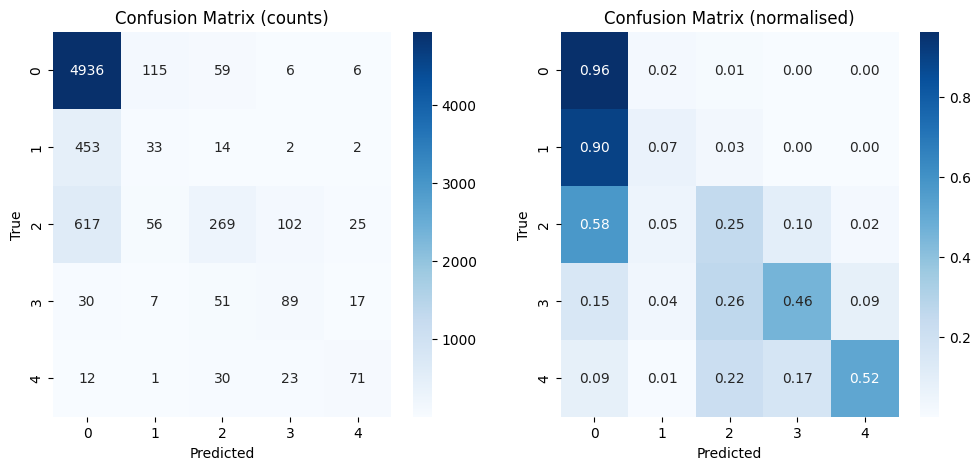


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88      5122
           1       0.16      0.07      0.09       504
           2       0.64      0.25      0.36      1069
           3       0.40      0.46      0.43       194
           4       0.59      0.52      0.55       137

    accuracy                           0.77      7026
   macro avg       0.52      0.45      0.46      7026
weighted avg       0.73      0.77      0.73      7026



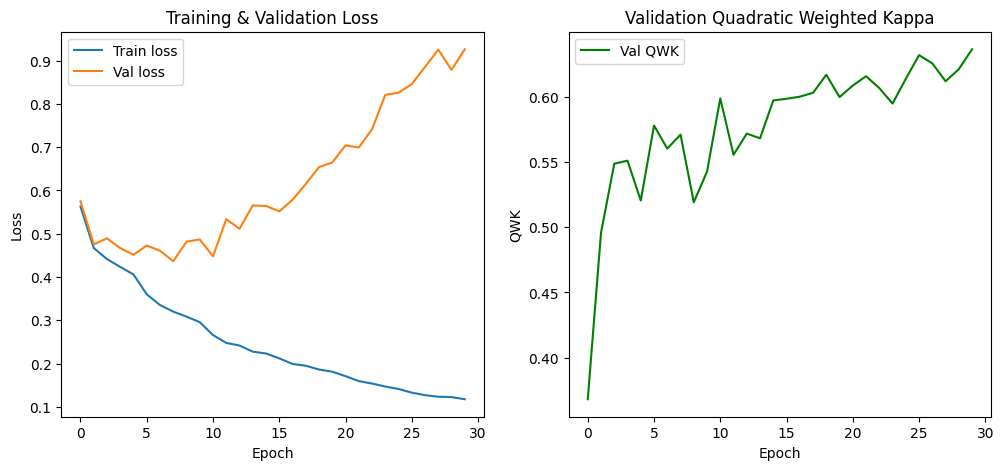

Model saved ✅


In [3]:
# =========================
# 1. Install
# =========================
!pip install timm -q

# =========================
# 2. Imports
# =========================
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset
import timm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score

# =========================
# 3. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 4. Dataset Path (UPDATED ONLY)
# =========================
csv_path = "/kaggle/input/datasets/bavadharaniravi/csvfile/trainLabels.csv"
img_dir = "/kaggle/input/datasets/bavadharaniravi/diabetic-retinopathy/processed"

# =========================
# 5. Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# =========================
# 🔥 6. Custom Dataset (REPLACEMENT)
# =========================
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0] + ".jpeg"
        label = int(self.df.iloc[idx, 1])

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# 7. Load Dataset
# =========================
dataset = RetinopathyDataset(csv_path, img_dir, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

# =========================
# 8. Model (DeiT-III)
# =========================
model = timm.create_model('deit3_small_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, 5)
model = model.to(device)

# =========================
# 9. Class Weights (UNCHANGED)
# =========================
class_counts = [470, 1023, 5247, 126, 160]

weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
weights = weights / weights.mean()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# =========================
# 10. Optimizer + Scheduler
# =========================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# =========================
# 11. Training
# =========================
epochs = 30

train_losses = []
val_losses = []
qwk_scores = []

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ===== METRICS =====
    acc = 100 * correct / total
    qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")
    qwk_scores.append(qwk)

    scheduler.step()

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Accuracy: {acc:.2f}%")
    print(f"QWK: {qwk:.4f}")

# =========================
# 12. Confusion Matrix
# =========================
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,5))

# LEFT: COUNTS
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (counts)")
plt.xlabel("Predicted")
plt.ylabel("True")

# RIGHT: NORMALIZED
plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title("Confusion Matrix (normalised)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# =========================
# 13. Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# =========================
# 14. Graphs
# =========================
plt.figure(figsize=(12,5))

# LOSS
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# QWK
plt.subplot(1,2,2)
plt.plot(qwk_scores, color="green", label="Val QWK")
plt.title("Validation Quadratic Weighted Kappa")
plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.legend()

plt.show()

# =========================
# 15. Save Model
# =========================
torch.save(model.state_dict(), "deit_model.pth")
print("Model saved ✅")